### Problem Statement ###
-PROBLEM : the bank is facing a growing number of closed accounts , currently managed through reactive measures that fail to prevent revenue loss 

- SOLUTION: we are deploying a mavhine learning initiative to predict customer churn using historical data 

- OUTCOME: by identifying high-risk customers early , we will enable targeted retention campaigns , reduce acquisition costs, and improve customer lifetime value(CLV)

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")

In [11]:
df.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape()

(10000, 12)

In [7]:
df.info()    ##this data has no null values since all the columns have 10000 non-null values. Also, we can see that the data types of all the columns are either int64 or object.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [12]:
df[df['churn'].isnull()]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


In [13]:
df.drop(df[df['churn'].isnull()].index, axis=0, inplace=True)  ##dropping the row with null value in the 'churn' column since it is the target variable and we cannot impute it.
                                                                ##Also, since there is only one row with null value in the 'churn' column, dropping it will not affect our analysis much.
                                                                ##inplace=True means that we are modifying the original dataframe and not creating a new one.

In [14]:
df.reset_index(drop= True, inplace=True)  ##resetting the index after dropping the row with null value in the 'churn' column. drop=True means that we are not adding the old index as a column in the new dataframe.

In [16]:
df[df['credit_score'].isnull()]  ##there are no null values in the 'credit_score' column as well. We can see that all the columns have 10000 non-null values.
df[(df['country'] == 'Spain')&(df['gender'] == 'Female')&(df['age']==43)&(df['tenure']==5)&(df['credit_score'].notnull())] ##if we had null value in this col we would find similar to the null datasets and put everyones avg of the similar datasets in the creditscore of the null dataset. But since there are no null values in the 'credit_score' column, we can skip this step.

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
4200,15751943,529,Spain,Female,43,5,0.00,2,0,0,79476.63,0
7458,15800049,728,Spain,Female,43,5,0.00,1,1,1,120088.17,0
8690,15756167,762,Spain,Female,43,5,134204.67,1,1,1,139971.01,0
9404,15792232,595,Spain,Female,43,5,0.00,2,0,0,105149.80,0


In [17]:
creditscore_mean = df[(df['country'] == 'Spain')&(df['gender'] == 'Female')&(df['age']==43)&(df['tenure']==5)&(df['credit_score'].notnull())]['credit_score'].mean()  ##this is how we would calculate the mean of the 'credit_score' column for the similar datasets if we had null values in the 'credit_score' column. But since there are no null values in the 'credit_score' column, we can skip this step.

In [18]:
df.loc[4200, 'credit_score'] = creditscore_mean  ##this is how we would impute the null value in the 'credit_score' column with the mean of the similar datasets if we had null values in the 'credit_score' column. But since there are no null values in the 'credit_score' column, we can skip this step.

In [ ]:
df.loc[4200, :] ##can check all columns of the row with index 4200 to see if there are any null values in any of the columns. But since there are no null values in any of the columns, we can skip this step.

customer_id         15751943
credit_score           653.5
country                Spain
gender                Female
age                       43
tenure                     5
balance                  0.0
products_number            2
credit_card                0
active_member              0
estimated_salary    79476.63
churn                      0
Name: 4200, dtype: object

### Dataset Cleaning finished ##
- now we will focus more on our target column"churn" or "exited"

In [ ]:
df['churn'].value_counts()  ##gives us an idea of the distribution of the target variable. We can see that there are 7963 customers who did not churn and 2036 customers who churned. This means that the data is imbalanced since the number of customers who did not churn is much higher than the number of customers who churned. This is something we need to keep in mind when we are building our model since it can affect the performance of our model. We will discuss how to handle imbalanced data in the next section.

churn
0    7963
1    2037
Name: count, dtype: int64

In [ ]:
df['credit_card'].value_counts() ##next important column
## we are checking the balance , a good balance is 50 50 or last 60 40 oterwise the data is skewed and we need to apply techniques like smote or undersampling to balance the data.

credit_card
1    7055
0    2945
Name: count, dtype: int64

In [22]:
df['active_member'].value_counts() ##next important column

active_member
1    5151
0    4849
Name: count, dtype: int64

In [23]:
df['products_number'].value_counts() ##next important column

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [ ]:
df.describe().T ##T here means transpose. This gives us the summary statistics of the numerical columns in the data. We can see that the mean age of the customers is 38.92 years, the mean credit score is 650.53, the mean balance is 76485.89, and the mean estimated salary is 100090.24. We can also see that the minimum age of the customers is 18 years, the minimum credit score is 350, the minimum balance is 0, and the minimum estimated salary is 11.58. The maximum age of the customers is 92 years, the maximum credit score is 850, the maximum balance is 250898.09, and the maximum estimated salary is 199992.48. The standard deviation of the age of the customers is 10.49 years, the standard deviation of the credit score is 96.65, the standard deviation of the balance is 62397.41, and the standard deviation of the estimated salary is 57510.50.
                ## we need to remove outliers otherwise it will mess up our model in models like knn or spm or linear regression. 

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505412e+02,96.645661,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


### HANDLING OUTLIERS ###

In [ ]:
mulcols=['age', 'credit_score', 'balance', 'estimated_salary']   ###only the cols required for prediction are taken

{'whiskers': [<matplotlib.lines.Line2D at 0x1b4ba0cdf70>,
 'caps': [<matplotlib.lines.Line2D at 0x1b4ba0ce2d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b4ba0cdd00>],
 'medians': [<matplotlib.lines.Line2D at 0x1b4ba0cedb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b4ba0cf020>],
 'means': []}

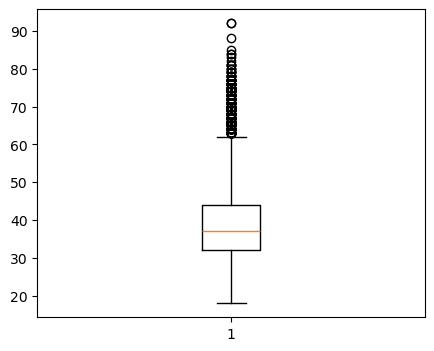

In [ ]:
plt.figure(figsize=(5, 4)) ##here figsize is the size of plot with width, height in inches.
plt.boxplot(x = df['age'])